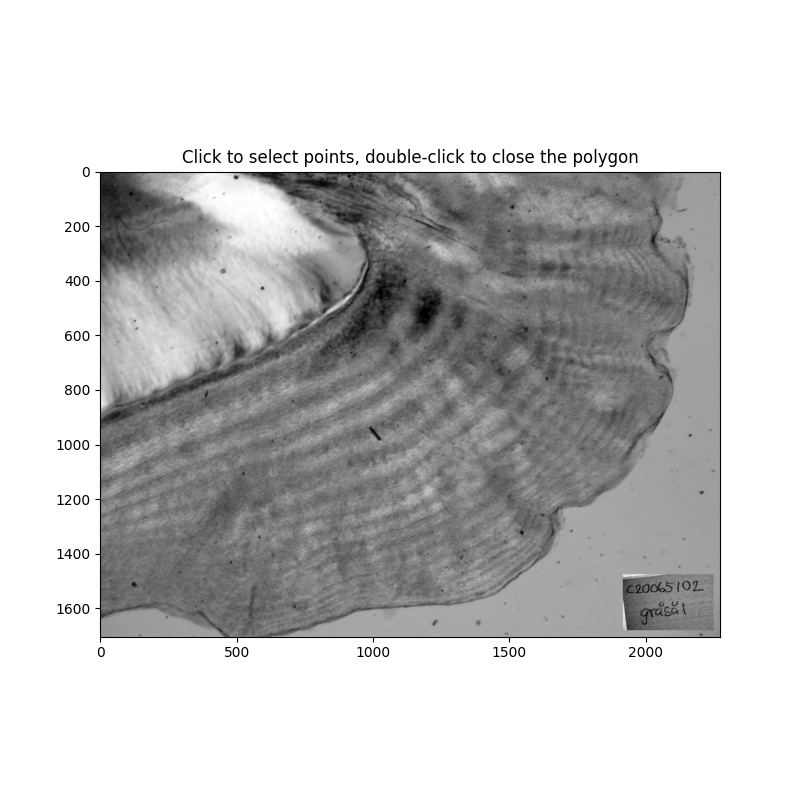

In [2]:
# === Enable Interactive Mode ===
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.widgets import PolygonSelector
import numpy as np
import cv2
from scipy.signal import find_peaks

import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']  # Support Unicode
matplotlib.rcParams['axes.unicode_minus'] = False

# ---------- Step 1. Read Image ----------
img_path = "c20065102.jpg"  # Change this path to your image
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Cannot find image file: {img_path}")

roi_polygon = []

# ---------- Step 2. Polygon Selection ----------
def onselect(verts):
    global roi_polygon
    roi_polygon = np.array(verts, dtype=np.int32)
    print(f"Selection completed, {len(roi_polygon)} vertices:\n{roi_polygon}")

    if len(roi_polygon) >= 3:
        plt.close()  # Automatically close the window
        extract_roi()  # Automatically extract ROI
    else:
        print("Not enough vertices, please select again.")

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(img, cmap="gray")
ax.set_title("Click to select points, double-click to close the polygon")

selector = PolygonSelector(
    ax, onselect,
    props=dict(color='r', lw=1.5, alpha=0.8)
)

plt.show()

In [3]:
def extract_roi():
    global roi_polygon, img
    mask = np.zeros_like(img, dtype=np.uint8)
    cv2.fillPoly(mask, [roi_polygon], 255)
    roi = cv2.bitwise_and(img, mask)
    x, y, w, h = cv2.boundingRect(roi_polygon)
    roi_cropped = roi[y:y + h, x:x + w]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(mask, cmap='gray')
    plt.title("Polygon Mask")

    plt.subplot(1, 2, 2)
    plt.imshow(roi_cropped, cmap='gray')
    plt.title("Cropped ROI")
    plt.tight_layout()
    plt.show()

In [4]:
if roi_polygon is None or len(roi_polygon) == 0:
    raise ValueError("No region selected. Please rerun the above cell and draw an ROI.")

# ---------- Step 1. Create Mask ----------
mask = np.zeros_like(img, dtype=np.uint8)
cv2.fillPoly(mask, [roi_polygon], 255)

# ---------- Step 2. Create White Background ----------
white_bg = np.full_like(img, 255, dtype=np.uint8)

# ---------- Step 3. Copy ROI onto White Background ----------
roi_whitebg = white_bg.copy()
roi_whitebg[mask == 255] = img[mask == 255]

# ---------- Step 4. Crop Bounding Box ----------
x, y, w, h = cv2.boundingRect(roi_polygon)
roi_cropped = roi_whitebg[y:y + h, x:x + w]


C:\ProgramData\anaconda3\envs\SML\Lib\site-packages\ipympl\backend_nbagg.py:342: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')


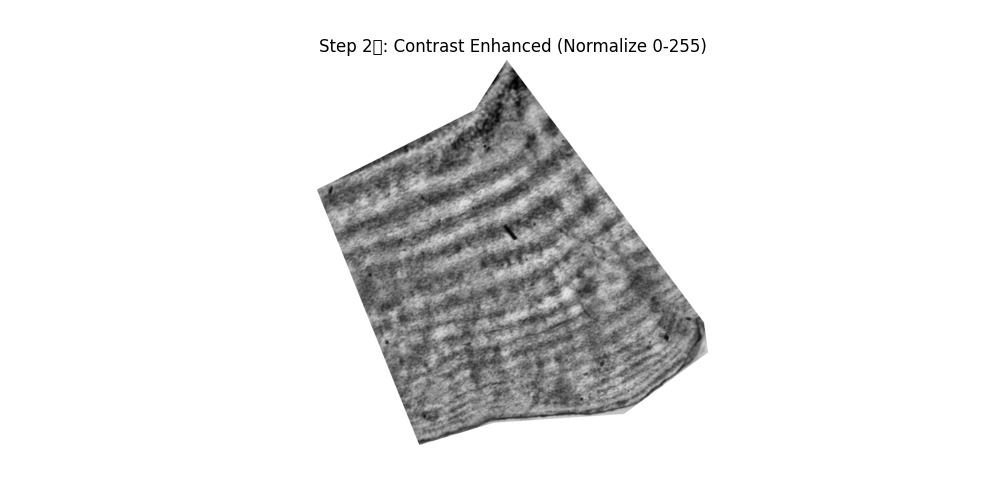

In [5]:
denoised = cv2.bilateralFilter(roi_cropped, d=5, sigmaColor=30, sigmaSpace=10)

# CLAHE + Normalization
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16,16))
enh = clahe.apply(denoised)

norm = cv2.normalize(enh, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(10,5))
plt.imshow(norm, cmap='gray')
plt.title("Step: Contrast Enhanced (Normalize 0-255)")
plt.axis('off')
plt.show()


In [6]:
def get_line_through_center(cx, cy, theta_deg, w, h):
    """Return the line passing through image center intersecting the boundaries."""
    dx, dy = np.cos(np.deg2rad(theta_deg)), np.sin(np.deg2rad(theta_deg))
    eps = 1e-9
    t = []
    if abs(dx) > eps:
        for X in (0, w - 1):
            Y = cy + (X - cx) / dx * dy
            if 0 <= Y <= h - 1:
                t.append((X - cx) / dx)
    if abs(dy) > eps:
        for Y in (0, h - 1):
            X = cx + (Y - cy) / dy * dx
            if 0 <= X <= w - 1:
                t.append((Y - cy) / dy)
    t1, t2 = np.min(t), np.max(t)
    return cx + t1 * dx, cy + t1 * dy, cx + t2 * dx, cy + t2 * dy


def bilinear_sample(img, x, y):
    """Vectorized bilinear interpolation."""
    h, w = img.shape
    x0, y0 = np.floor(x).astype(int), np.floor(y).astype(int)
    x0, y0 = np.clip(x0, 0, w - 2), np.clip(y0, 0, h - 2)
    a, b = x - x0, y - y0
    I00, I10 = img[y0, x0], img[y0, x0 + 1]
    I01, I11 = img[y0 + 1, x0], img[y0 + 1, x0 + 1]
    return ((1 - a) * (1 - b) * I00 + a * (1 - b) * I10 + (1 - a) * b * I01 + a * b * I11)


def analyze_profile(roi, avg_halfwidth=5, dist=10, prom=50):
    """Main function: detect dominant orientation, sample along line, and find peaks."""
    h, w = roi.shape

    # --- 1. Compute gradient and main direction ---
    gx, gy = cv2.Scharr(roi, cv2.CV_32F, 1, 0), cv2.Scharr(roi, cv2.CV_32F, 0, 1)
    angle, mag = np.arctan2(gy, gx), np.hypot(gx, gy)
    wgt = mag ** 2
    theta = 0.5 * np.arctan2(np.sum(wgt * np.sin(2 * angle)), np.sum(wgt * np.cos(2 * angle)))
    theta_deg = (np.degrees(theta) + 180) % 180

    # --- 2. Sample line through center and average multiple profiles ---
    cx, cy = w // 2, h // 2
    x1, y1, x2, y2 = get_line_through_center(cx, cy, theta_deg, w, h)
    N = int(np.hypot(x2 - x1, y2 - y1))
    x = np.linspace(x1, x2, N, endpoint=False)
    y = np.linspace(y1, y2, N, endpoint=False)
    dxp, dyp = -np.sin(np.deg2rad(theta_deg)), np.cos(np.deg2rad(theta_deg))
    profiles = [bilinear_sample(roi, x + i * dxp, y + i * dyp) for i in range(-avg_halfwidth, avg_halfwidth + 1)]
    profile = np.mean(profiles, axis=0)

    # --- 3. Peak detection ---
    peaks, _ = find_peaks(-profile, distance=dist, prominence=prom)
    print(f"Dominant direction: {theta_deg:.2f}°, Detected {len(peaks)} valleys")

    # --- 4. Visualization ---
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    ax[0].imshow(roi, cmap='gray')
    ax[0].plot([x1, x2], [y1, y2], 'r-', lw=2)
    if len(peaks):
        px, py = x[peaks], y[peaks]
        ax[0].plot(px, py, 'bo', ms=5)
        for i, (xx, yy) in enumerate(zip(px, py), 1):
            ax[0].text(xx + 4, yy, f"{i}", color='cyan', fontsize=8,
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.4))
    ax[0].set_title(f"ROI + Profile Line ({theta_deg:.1f}°)")
    ax[0].axis('off')

    ax[1].plot(profile, 'k', lw=1.2)
    if len(peaks):
        ax[1].plot(peaks, profile[peaks], 'rx')
    if len(peaks) > 1:
        ax[1].set_title(f"{len(peaks)} valleys detected\nMean spacing: {np.mean(np.diff(peaks)):.1f} px")
    else:
        ax[1].set_title("Gray-level Profile")
    ax[1].grid(True, ls='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


Dominant direction: 60.68°, Detected 18 valleys


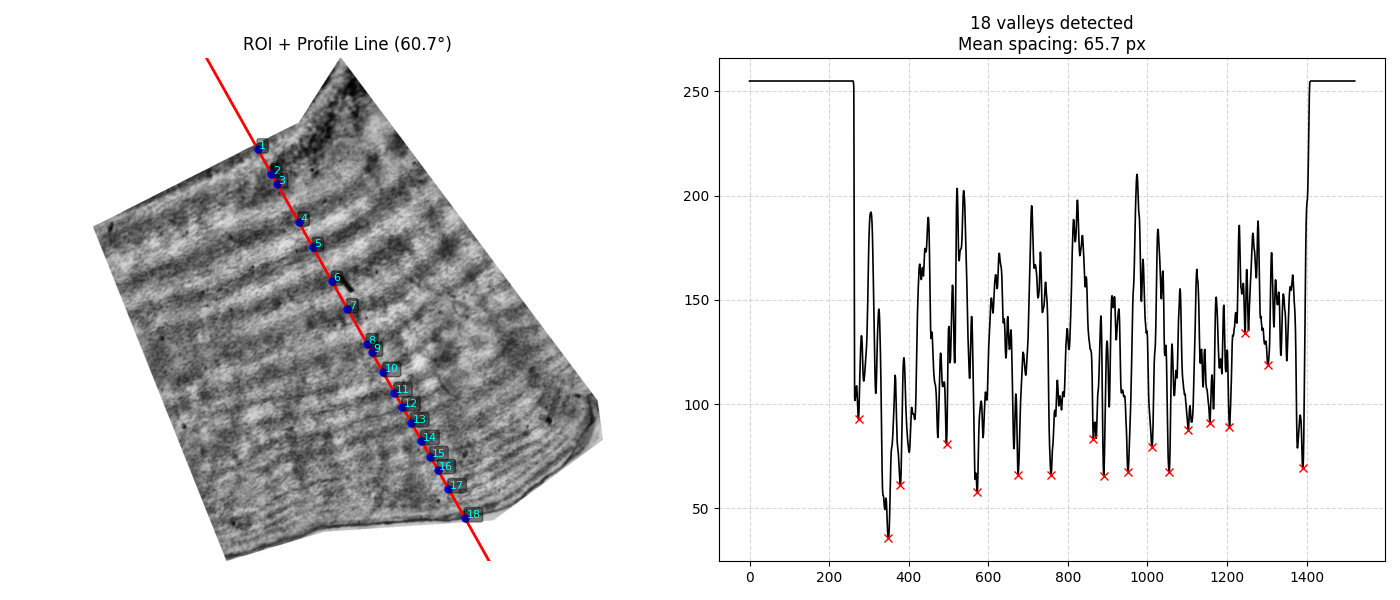

In [7]:
# Run the analysis
roi = norm.astype(np.float32)
analyze_profile(roi, avg_halfwidth=5, dist=10, prom=50)